In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from HARey.projections import stereo_polar

In [2]:
file_name = '/home/giacomo/Downloads/mw.json'

with open(file_name, 'r') as file:
    data = json.load(file)

In [3]:
import numpy as np

def lonlat_to_xyz(lon, lat):
    lon = np.deg2rad(lon)
    lat = np.deg2rad(lat)

    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)

    return np.array([x, y, z])


def xyz_to_lonlat(v):
    x, y, z = v
    lon = np.rad2deg(np.arctan2(y, x))
    lat = np.rad2deg(np.arctan2(z, np.sqrt(x*x + y*y)))
    return np.array([lon, lat])


def smooth_sphere_polygon(points, iterations=5, alpha=0.3):
    pts = np.asarray(points)

    # remove duplicate closing point if present
    closed = np.allclose(pts[0], pts[-1])
    if closed:
        pts = pts[:-1]

    xyz = np.array([lonlat_to_xyz(lon, lat) for lon, lat in pts])
    n = len(xyz)

    for _ in range(iterations):
        new_xyz = xyz.copy()

        for i in range(n):
            prev_i = (i - 1) % n
            next_i = (i + 1) % n

            avg = (xyz[prev_i] + xyz[next_i]) / 2
            new = xyz[i] + alpha * (avg - xyz[i])

            new /= np.linalg.norm(new)
            new_xyz[i] = new

        xyz = new_xyz

    smoothed = np.array([xyz_to_lonlat(v) for v in xyz])

    # re-close polygon
    if closed:
        smoothed = np.vstack([smoothed, smoothed[0]])

    return smoothed

In [4]:
luminosity_levels = [(data['features'][i]['geometry']['coordinates'][0]) for i in range(5)]
luminosity_levels = [[smooth_sphere_polygon(np.array(ring), iterations=40, alpha=0.35) for ring in rings] for rings in luminosity_levels]

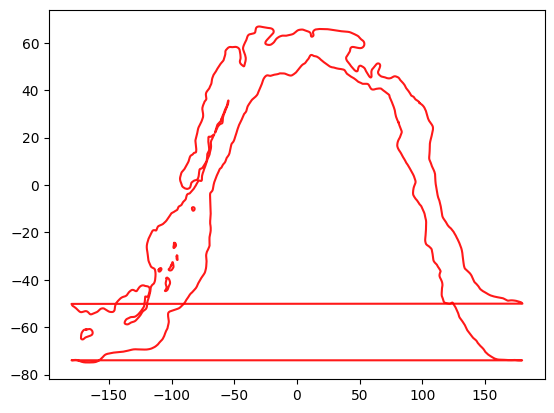

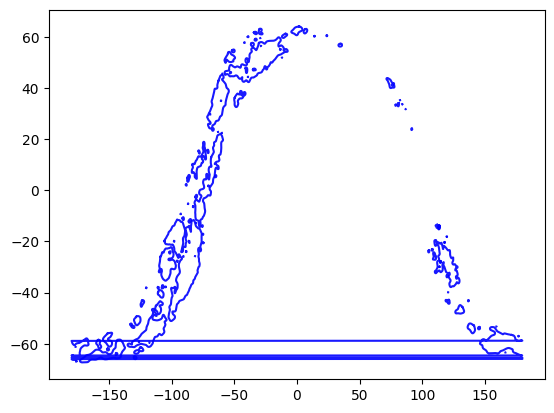

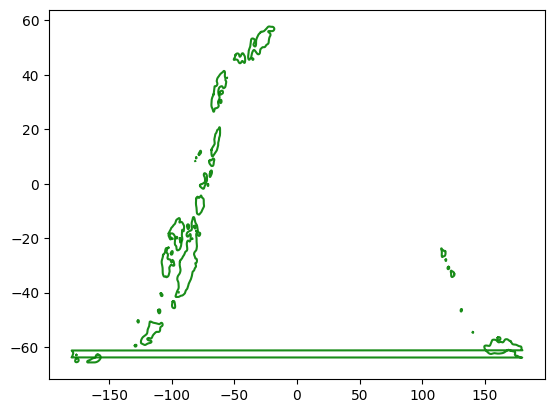

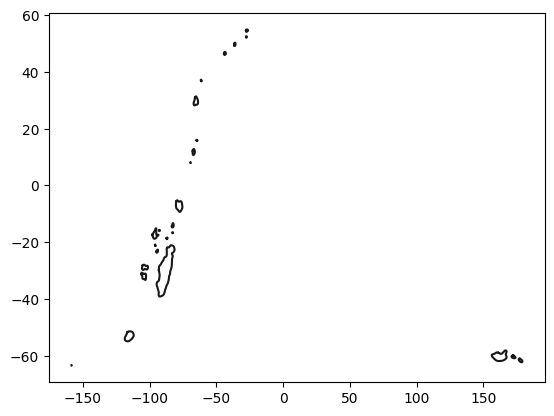

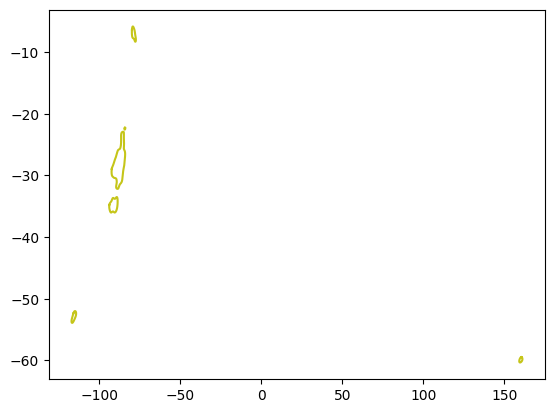

In [5]:
for level, color in zip(luminosity_levels, ['r', 'b', 'g', 'k', 'y']):
    for ring in level:
        x,y = zip(*ring)
        plt.plot(x,y, color, alpha=0.9)
    plt.show()

In [6]:
def one_hot_encode(a):
    # Compute rising edges (consider also the first value if True)
    a_rising = np.r_[False, a]
    rising_edges = np.argwhere(a_rising[1:] & ~a_rising[:-1]).flatten()

    # Compute falling edges (consider also the last value if True)
    a_falling = np.r_[a, False]
    falling_edges = np.argwhere(~a_falling[1:] & a_falling[:-1]).flatten() + 1

    masks = []
    # For each region between edges, return a mask of that region
    for rising, falling in zip(rising_edges, falling_edges):
        # Extend the right border by one
        mask = np.zeros_like(a).astype(bool)
        mask[rising:falling] = True
        masks.append(mask)

    return masks

In [7]:
def get_segments(ring, borders):
    
    inside = lambda x,y : (x >= borders[0]) & (x<= borders[1])
    segments = []
    for mask in one_hot_encode(inside(*ring.T)):
        segment = ring[mask]

        get_closest_border = lambda x: borders[0] if np.abs(x[0] - borders[0]) < np.abs(x[0] - borders[1]) else borders[1]
        
        if not mask[0]:
            start = segment[0]
            start_border = get_closest_border(start)        
            connect_start = np.array((start_border, start[1])).reshape((1,2))
            segment = np.concatenate([connect_start, segment])

        if not mask[-1]:
            end = segment[-1]
            end_border = get_closest_border(end)        
            connect_end = np.array((end_border, end[1])).reshape((1,2))  
            segment = np.concatenate([segment, connect_end])  
        
        segments.append(segment)
        
    return segments

In [8]:
def merge_segments(segments):
    merged_segments = []
    used = [False]*len(segments)

    for i in range(len(segments)):
        for j in range(len(segments)):
            if np.all(segments[i][0] == segments[j][-1]) and not i==j:
                used[i], used[j] = True, True
                merged_segments.append(np.concatenate([segments[j], segments[i]]))

        if not used[i]:
            merged_segments.append(segments[i])
            
    return merged_segments
        

# From the top again, adding more levels

In [9]:
def join_segs(segments, joins, reverse=[]):
    rings = []
    for ring_indexes in joins:
        ring = []
        for index in ring_indexes:
            if index in reverse:
                ring.extend(list(segments[index][::-1]))
            else:
                ring.extend(list(segments[index]))

        rings.append(np.array(ring))

    return rings  

In [10]:
shapes = {i: [] for i in range(5)}

/tmp/ipykernel_95952/3590457374.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv', len(segments))  # generates 30 distinct colors


[[0]]


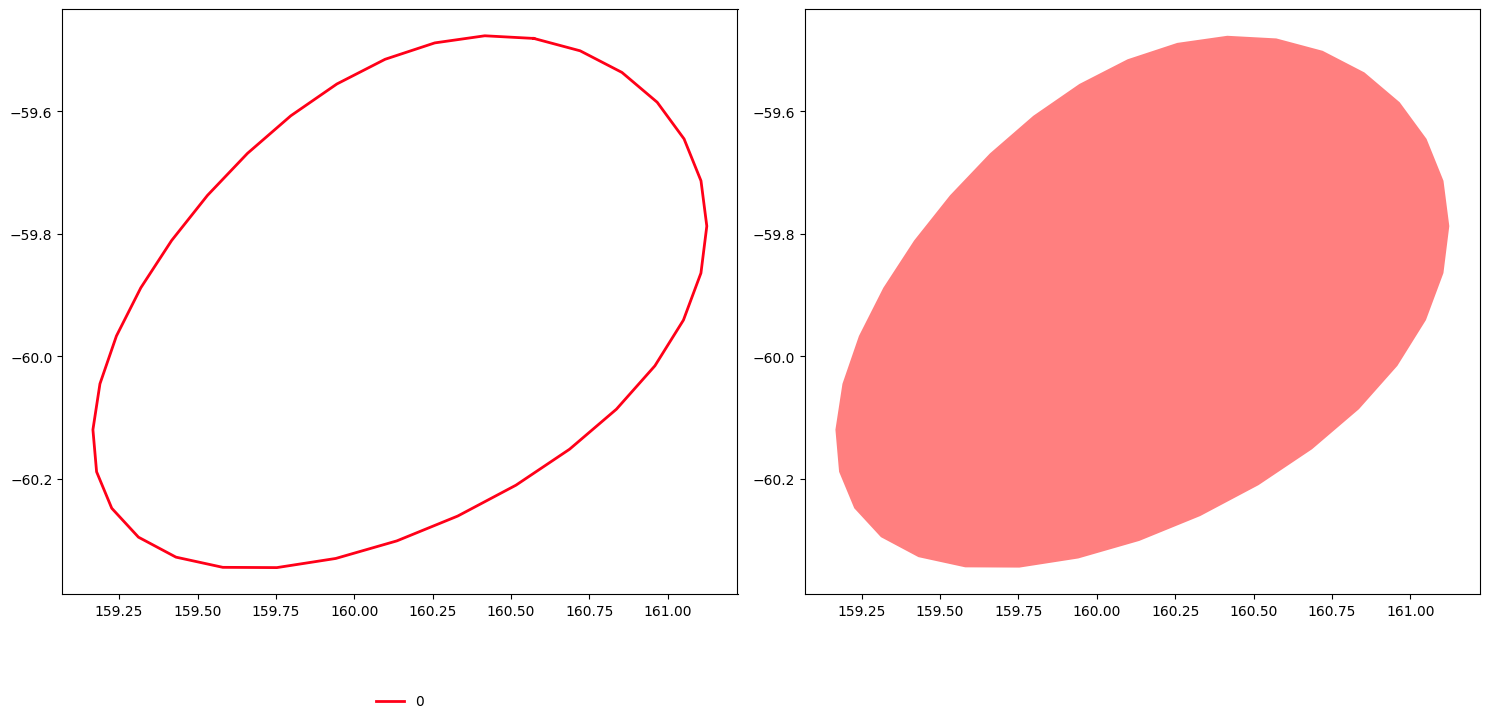

In [485]:
segments = []

for ring in luminosity_levels[4]:
    segments.extend(merge_segments(get_segments(ring, borders=(-60, 180))))

cmap = plt.cm.get_cmap('hsv', len(segments))  # generates 30 distinct colors
linestyles = ['-', ':']

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,8))

#segments = [*segments, [segments[4][0]]]

for i, segment in enumerate(segments):
    x,y = zip(*segment)
    linestyle = linestyles[i % len(linestyles)]
    ax1.plot(x, y, color = cmap(i), ls=linestyle, lw=2, label=f'{i}')

joins = [[i] for i in range(len(segments))]
#joins = [[0,1]]
print(joins)

shape_rings = join_segs(segments, joins=joins, reverse=[8,9,10])
for ring in shape_rings:
    x,y = zip(*ring)
    ax2.fill(x, y, 'r', alpha=0.5)
ax1.set_aspect('auto')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

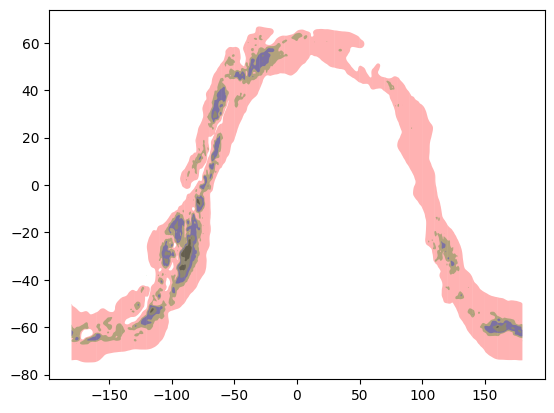

In [486]:
for shape in shape_rings:
    if not np.all(shape[0]==shape[-1]):
        shape = np.vstack((shape, shape[0]))
        print('Closing shape')

shapes[4].extend(shape_rings)

for color, level in zip(['r', 'g', 'b', 'y', 'k'], shapes.values()):
    for shape in level:
        x, y = zip(*shape)
        x = np.array(x)
        y = np.array(y)

        plt.fill(x,y, color, alpha=0.3)

In [487]:
shapes_list = {i:[shape.tolist() for shape in shapes[i]] for i in shapes}

In [488]:

with open('HARey/mw_clean_10_deg.json', 'w') as f:
   json.dump(shapes_list, f)


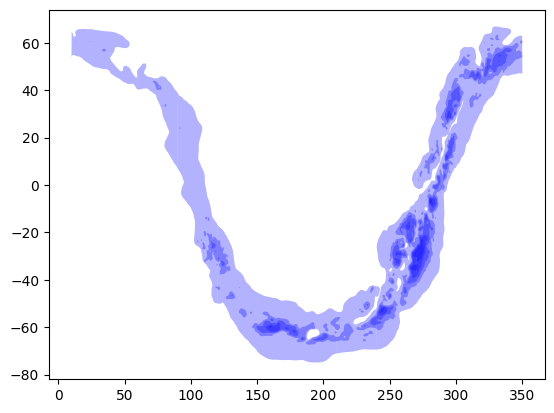

In [508]:
for color, level in zip(['r', 'g', 'b', 'y', 'k'], shapes_list.values()):
    for shape in level:
        x, y = zip(*shape)
        x = np.array(x)
        y = np.array(y)
        x = x%360
        mask = (x >10) & (x < 350)
        plt.fill(x[mask],y[mask], 'b', alpha=0.3)

In [192]:
import numpy as np

def smooth_points(points, iterations=5, alpha=0.5, closed=True):
    """
    Laplacian smoothing for 2D points.

    points: Nx2 numpy array
    iterations: number of smoothing passes
    alpha: smoothing strength (0-1)
    closed: whether shape is closed

    Endpoints are preserved for open polylines.
    """
    
    pts = points.astype(float).copy()
    n = len(pts)

    for _ in range(iterations):
        new_pts = pts.copy()

        for i in range(n):
            
            if not closed and (i == 0 or i == n-1):
                continue  # preserve endpoints

            prev_i = (i - 1) % n
            next_i = (i + 1) % n

            neighbor_avg = (pts[prev_i] + pts[next_i]) / 2

            new_pts[i] = pts[i] + alpha * (neighbor_avg - pts[i])

        pts = new_pts

    return pts

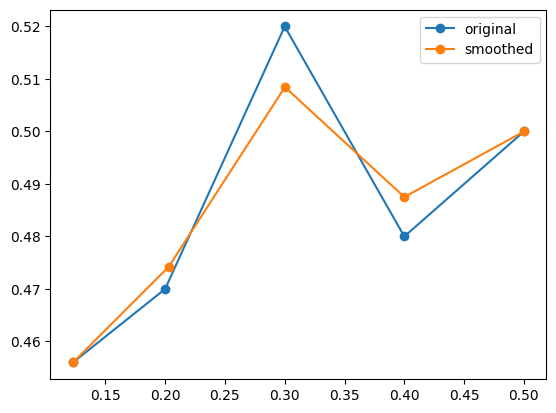

In [193]:
import matplotlib.pyplot as plt
import numpy as np

points = np.array([
    [0.123, 0.456],
    [0.200, 0.470],
    [0.300, 0.520],
    [0.400, 0.480],
    [0.500, 0.500]
])

smooth = smooth_points(points, iterations=3, alpha=0.1, closed=False)

plt.plot(points[:,0], points[:,1], 'o-', label="original")
plt.plot(smooth[:,0], smooth[:,1], 'o-', label="smoothed")
plt.legend()
plt.show()

In [194]:
ring = luminosity_levels[4][0]

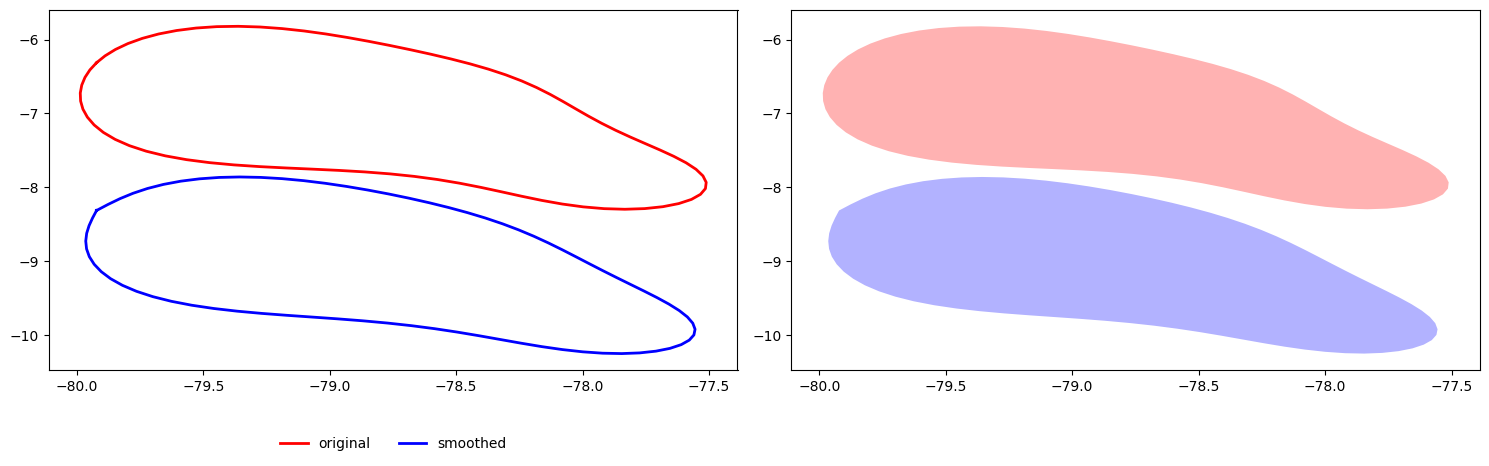

In [195]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,5))

x,y = zip(*ring)
ax1.plot(x, y, color = 'r', ls='-', lw=2, label='original', alpha=1)
smooth = smooth_sphere(np.array(ring), iterations=30, alpha=0.2, closed=False)
ax1.plot(smooth[:,0], smooth[:,1]-2, 'b-', lw=2, label='smoothed')

ax2.fill(x, y, 'r', alpha=0.3)
ax2.fill(smooth[:,0], smooth[:,1]-2, 'b', alpha=0.3)


ax1.set_aspect('auto')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, frameon=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()